# 04 Model Comparison (Week 5)

This notebook completes the Week 5 task by comparing the Week 4 linear-regression baseline against a `DecisionTreeRegressor` and a `RandomForestRegressor` using the same time-based train/test split.


## Week 5 Goal

The goal for Week 5 is to try additional models beyond the baseline, compare their performance on the same holdout month, and document the strengths and weaknesses of each model. To keep the comparison fair, all models use the same preprocessed train/test datasets from Week 3.


In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("ggplot")
RANDOM_STATE = 42


In [38]:
output_dir = Path("../outputs")
train_path = output_dir / "train_preprocessed.csv"
test_path = output_dir / "test_preprocessed.csv"

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        "Run 02_preprocessing.ipynb first so the processed train/test files exist."
    )

train_df = pd.read_csv(train_path, parse_dates=["CloseDate", "close_month"])
test_df = pd.read_csv(test_path, parse_dates=["CloseDate", "close_month"])

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(
    f"Train months: {sorted(train_df['close_month'].dt.strftime('%Y-%m').unique().tolist())}"
)
print(
    f"Test month: {sorted(test_df['close_month'].dt.strftime('%Y-%m').unique().tolist())}"
)
display(train_df.head())


Train rows: 59,345
Test rows: 12,007
Train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test month: ['2026-05']


,ClosePrice,CloseDate,close_month,ListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,Latitude,Longitude,DaysOnMarket,property_age,log_living_area,bathrooms_per_bedroom,CountyOrParish
0,1250000.00,2025-11-30,2025-11-01,1250000.00,1027.00,3.00,2.00,5913.00,1961.00,33.68,-118.00,0.00,64.00,6.94,0.67,Orange
1,2299995.00,2025-11-20,2025-11-01,2299995.00,1129.00,3.00,1.00,18432.00,1949.00,37.26,-121.93,0.00,76.00,7.03,0.33,Santa Clara
2,810000.00,2025-11-26,2025-11-01,799900.00,1619.00,4.00,3.00,5300.00,1978.00,32.56,-117.06,0.00,47.00,7.39,0.75,San Diego
3,925000.00,2025-11-17,2025-11-01,925000.00,2872.00,5.00,3.00,5272.00,2000.00,32.58,-117.02,0.00,25.00,7.96,0.60,San Diego
4,1300000.00,2025-11-25,2025-11-01,1300000.00,1727.00,3.00,2.00,10500.00,1950.00,35.55,-120.71,0.00,75.00,7.45,0.67,San Luis Obispo


## Modeling Features

To stay consistent with the retained Week 4 baseline, the feature set keeps the simplified location strategy: `CountyOrParish` is the only categorical geography field, while `City` and `PostalCode` remain excluded.


In [39]:
target_col = "ClosePrice"
feature_cols = [
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "property_age",
    "log_living_area",
    "bathrooms_per_bedroom",
    "CountyOrParish",
]

missing_cols = [col for col in feature_cols if col not in train_df.columns]
if missing_cols:
    raise ValueError(f"Missing required feature columns: {missing_cols}")

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [col for col in feature_cols if col not in numeric_features]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(feature_cols)


Numeric features: 12
Categorical features: 1
['ListPrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'Latitude', 'Longitude', 'DaysOnMarket', 'property_age', 'log_living_area', 'bathrooms_per_bedroom', 'CountyOrParish']


In [40]:
def build_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


models = {
    "LinearRegression": Pipeline(
        steps=[
            ("preprocess", build_preprocessor(scale_numeric=True)),
            ("model", LinearRegression()),
        ]
    ),
    "DecisionTree": Pipeline(
        steps=[
            ("preprocess", build_preprocessor(scale_numeric=False)),
            (
                "model",
                DecisionTreeRegressor(
                    max_depth=8,
                    min_samples_split=200,
                    min_samples_leaf=100,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("preprocess", build_preprocessor(scale_numeric=False)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=400,
                    max_depth=10,
                    min_samples_split=100,
                    min_samples_leaf=25,
                    max_features="sqrt",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}


In [41]:
results = []
predictions_by_model = {}
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    ape = (y_test - preds).abs() / y_test

    results.append(
        {
            "model_name": model_name,
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds),
            "MAPE": ape.mean(),
            "MdAPE": ape.median(),
        }
    )
    predictions_by_model[model_name] = preds
    fitted_models[model_name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values(["R2", "MAE"], ascending=[False, True])
    .reset_index(drop=True)
)
display(results_df)

best_model_name = results_df.loc[0, "model_name"]
best_model = fitted_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]
print(f"Best Week 5 model: {best_model_name}")


,model_name,MAE,RMSE,R2,MAPE,MdAPE
0,LinearRegression,176134.11,1010179.09,0.64,0.20,0.08
1,RandomForest,350910.15,1294788.70,0.40,0.41,0.19
2,DecisionTree,202766.88,1319878.01,0.38,0.23,0.07


Best Week 5 model: LinearRegression


## Model Comparison Charts

The plots below compare the three models on the same holdout month so we can see whether tree-based models improve on the linear-regression baseline.


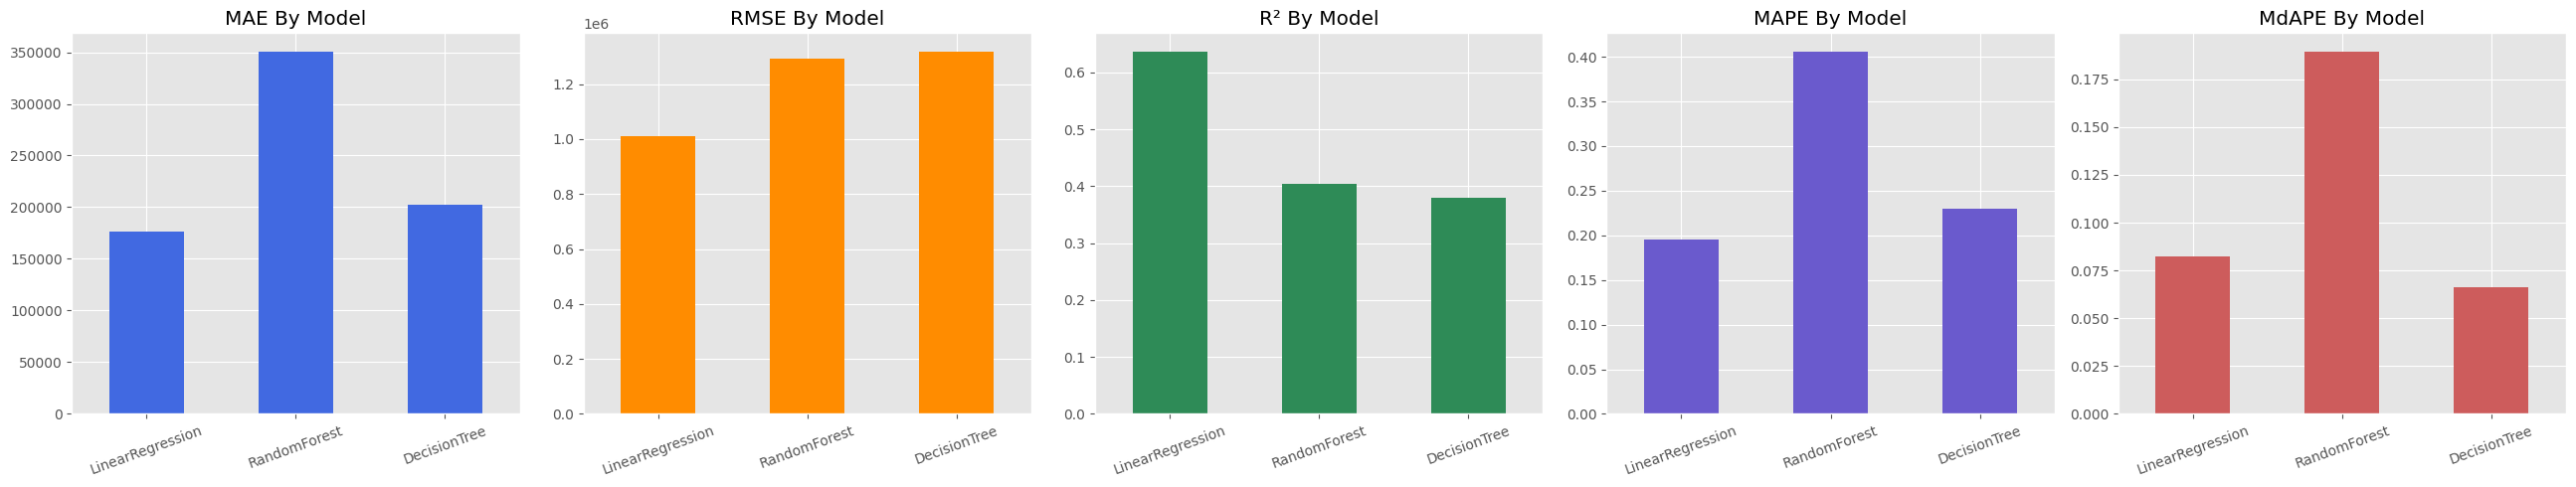

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))

results_df.plot(
    x="model_name", y="MAE", kind="bar", legend=False, ax=axes[0], color="royalblue"
)
axes[0].set_title("MAE By Model")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

results_df.plot(
    x="model_name", y="RMSE", kind="bar", legend=False, ax=axes[1], color="darkorange"
)
axes[1].set_title("RMSE By Model")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

results_df.plot(
    x="model_name", y="R2", kind="bar", legend=False, ax=axes[2], color="seagreen"
)
axes[2].set_title("R² By Model")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)

results_df.plot(
    x="model_name", y="MAPE", kind="bar", legend=False, ax=axes[3], color="slateblue"
)
axes[3].set_title("MAPE By Model")
axes[3].set_xlabel("")
axes[3].tick_params(axis="x", rotation=20)

results_df.plot(
    x="model_name", y="MdAPE", kind="bar", legend=False, ax=axes[4], color="indianred"
)
axes[4].set_title("MdAPE By Model")
axes[4].set_xlabel("")
axes[4].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


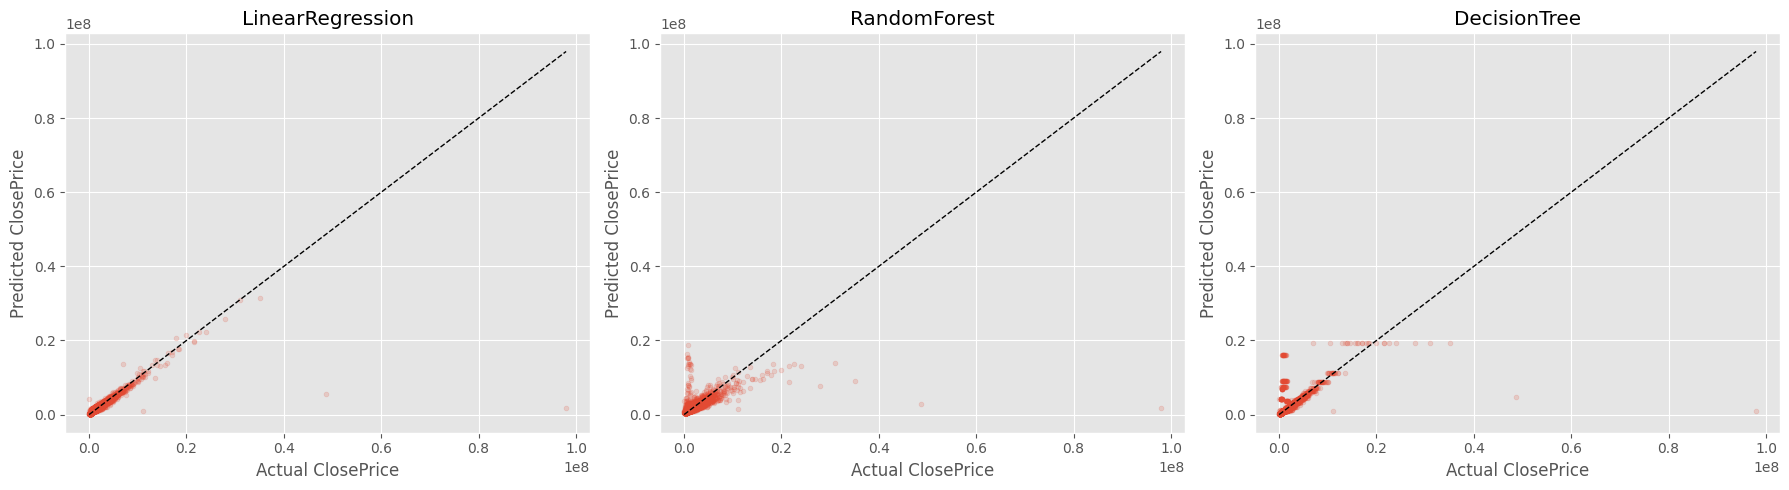

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, results_df["model_name"]):
    preds = predictions_by_model[model_name]
    ax.scatter(y_test, preds, alpha=0.18, s=12)
    plot_max = max(y_test.max(), preds.max())
    ax.plot([0, plot_max], [0, plot_max], linestyle="--", color="black", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Actual ClosePrice")
    ax.set_ylabel("Predicted ClosePrice")

plt.tight_layout()
plt.show()


In [44]:
comparison_df = test_df[["CloseDate", "close_month"]].copy()
comparison_df["actual"] = y_test.values

for model_name, preds in predictions_by_model.items():
    comparison_df[f"pred_{model_name}"] = preds
    comparison_df[f"abs_error_{model_name}"] = (comparison_df["actual"] - preds).abs()

best_residual = comparison_df["actual"] - best_predictions
comparison_df["best_model_name"] = best_model_name
comparison_df["best_predicted"] = best_predictions
comparison_df["best_residual"] = best_residual
comparison_df["best_abs_error"] = best_residual.abs()
comparison_df["best_ape"] = comparison_df["best_abs_error"] / comparison_df["actual"]

display(comparison_df.head())


,CloseDate,close_month,actual,pred_LinearRegression,abs_error_LinearRegression,pred_DecisionTree,abs_error_DecisionTree,pred_RandomForest,abs_error_RandomForest,best_model_name,best_predicted,best_residual,best_abs_error,best_ape
0,2026-05-28,2026-05-01,8712500.00,7876944.84,835555.16,8806338.04,93838.04,5775891.31,2936608.69,LinearRegression,7876944.84,835555.16,835555.16,0.10
1,2026-05-29,2026-05-01,1100000.00,1795529.81,695529.81,1279768.18,179768.18,2653287.11,1553287.11,LinearRegression,1795529.81,-695529.81,695529.81,0.63
2,2026-05-28,2026-05-01,1625000.00,1379430.00,245570.00,1279768.18,345231.82,1111740.36,513259.64,LinearRegression,1379430.00,245570.00,245570.00,0.15
3,2026-05-15,2026-05-01,1560000.00,1665437.54,105437.54,1528912.21,31087.79,1411098.82,148901.18,LinearRegression,1665437.54,-105437.54,105437.54,0.07
4,2026-05-29,2026-05-01,605000.00,629705.61,24705.61,592906.97,12093.03,1377464.13,772464.13,LinearRegression,629705.61,-24705.61,24705.61,0.04


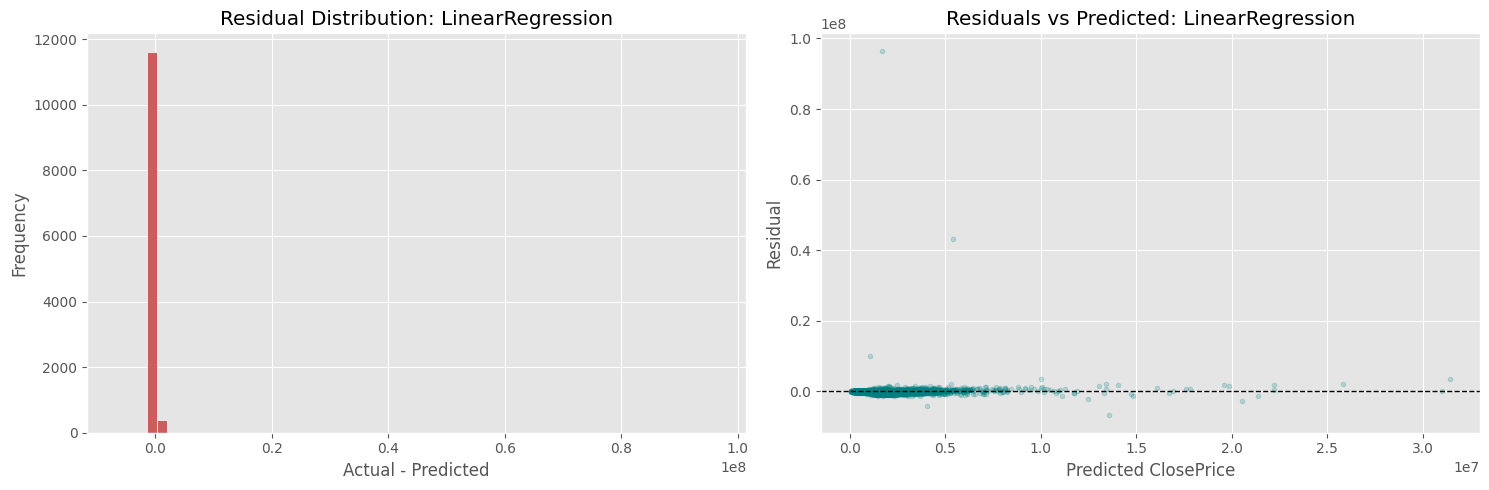

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparison_df["best_residual"].plot(
    kind="hist", bins=60, ax=axes[0], color="indianred", edgecolor="white"
)
axes[0].set_title(f"Residual Distribution: {best_model_name}")
axes[0].set_xlabel("Actual - Predicted")

axes[1].scatter(
    comparison_df["best_predicted"],
    comparison_df["best_residual"],
    alpha=0.22,
    s=12,
    color="teal",
)
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title(f"Residuals vs Predicted: {best_model_name}")
axes[1].set_xlabel("Predicted ClosePrice")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


/tmp/ipykernel_79372/3004166612.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("price_band")


,price_band,row_count,median_actual,mean_abs_error,median_ape
0,"(11899.999, 448599.4]",1201,369000.00,88215.63,0.20
1,"(448599.4, 580000.0]",1217,518492.00,94093.03,0.15
2,"(580000.0, 695892.0]",1184,640000.00,107255.97,0.11
3,"(695892.0, 807500.0]",1202,750000.00,146766.80,0.09
4,"(807500.0, 930000.0]",1223,866000.00,189470.50,0.08
5,"(930000.0, 1125000.0]",1207,1015000.00,189723.95,0.07
6,"(1125000.0, 1350000.0]",1174,1235000.00,171975.94,0.06
7,"(1350000.0, 1690000.0]",1207,1500000.00,162642.09,0.05
8,"(1690000.0, 2400000.0]",1198,1950000.00,163384.25,0.04
9,"(2400000.0, 97972500.0]",1194,3300000.00,449176.73,0.06


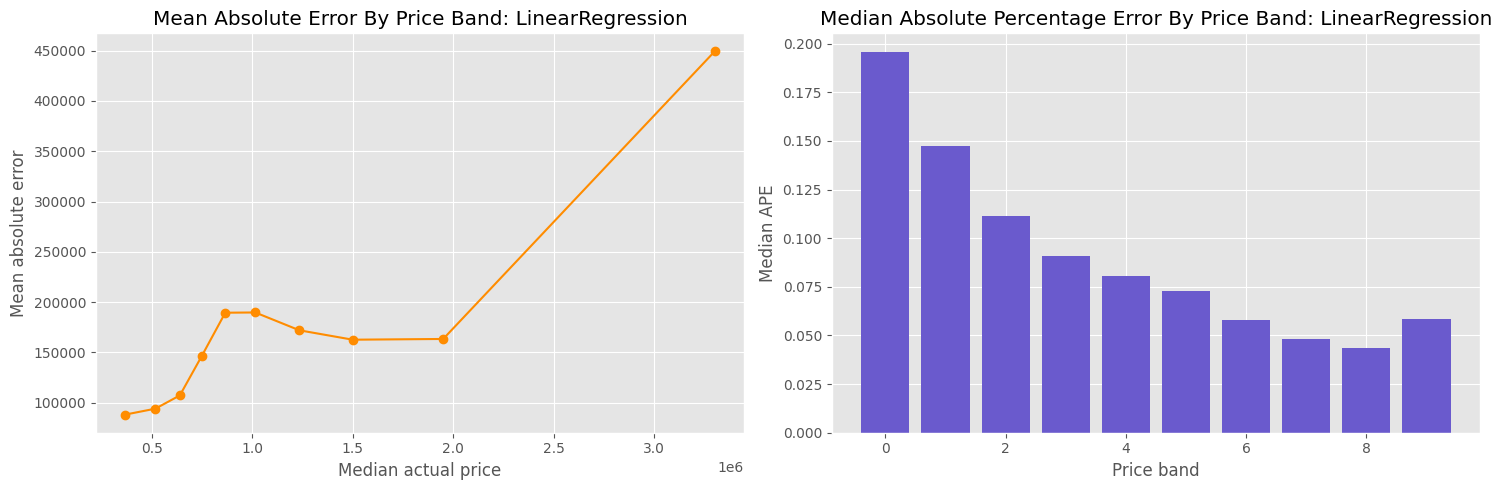

In [46]:
segment_summary = (
    comparison_df.assign(
        price_band=pd.qcut(comparison_df["actual"], q=10, duplicates="drop")
    )
    .groupby("price_band")
    .agg(
        row_count=("actual", "size"),
        median_actual=("actual", "median"),
        mean_abs_error=("best_abs_error", "mean"),
        median_ape=("best_ape", "median"),
    )
    .reset_index()
)

display(segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(
    segment_summary["median_actual"],
    segment_summary["mean_abs_error"],
    marker="o",
    color="darkorange",
)
axes[0].set_title(f"Mean Absolute Error By Price Band: {best_model_name}")
axes[0].set_xlabel("Median actual price")
axes[0].set_ylabel("Mean absolute error")

axes[1].bar(
    range(len(segment_summary)), segment_summary["median_ape"], color="slateblue"
)
axes[1].set_title(f"Median Absolute Percentage Error By Price Band: {best_model_name}")
axes[1].set_xlabel("Price band")
axes[1].set_ylabel("Median APE")

plt.tight_layout()
plt.show()


## Model Behavior Notes

Use the results table and plots above to compare the tradeoffs:

1. `LinearRegression` is still the best overall model in this comparison and remains the strongest benchmark.
2. `DecisionTree` became much more stable after tuning, but it still performs below the baseline on the holdout month.
3. `RandomForest` is the strongest tree-based model after tuning, but it still does not beat `LinearRegression` on `R²`.
4. The comparison table now includes `R²`, `MAPE`, and `MdAPE`, so every model is evaluated on the same standard.


,feature,coefficient,abs_coefficient
0,num__ListPrice,1339453.40,1339453.40
9,num__property_age,1030092.81,1030092.81
5,num__YearBuilt,1016561.40,1016561.40
50,cat__CountyOrParish_San Diego,603807.52,603807.52
54,cat__CountyOrParish_San Mateo,274983.92,274983.92
51,cat__CountyOrParish_San Francisco,233543.01,233543.01
56,cat__CountyOrParish_Santa Clara,217951.40,217951.40
12,cat__CountyOrParish_Alameda,140534.53,140534.53
24,cat__CountyOrParish_Imperial,-122049.33,122049.33
3,num__BathroomsTotalInteger,-112800.27,112800.27


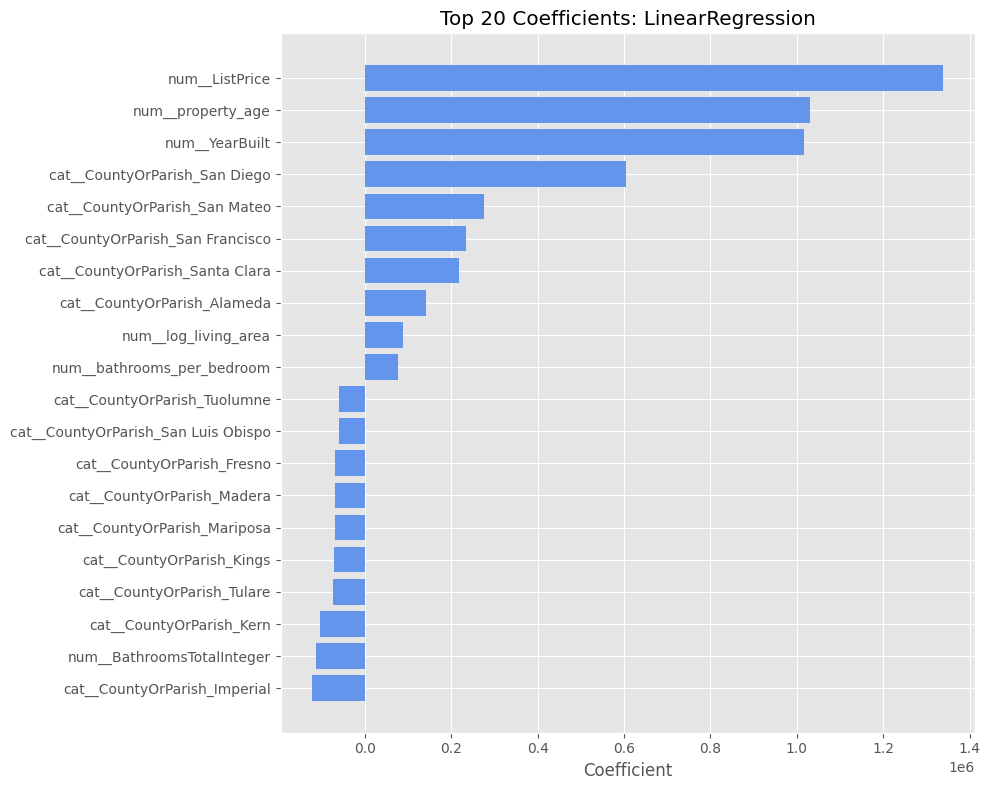

In [47]:
best_estimator = best_model.named_steps["model"]
best_preprocessor = best_model.named_steps["preprocess"]
feature_names = best_preprocessor.get_feature_names_out()

if hasattr(best_estimator, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": best_estimator.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    display(importance_df.head(20))

    top_importances = importance_df.head(20).sort_values("importance")
    plt.figure(figsize=(10, 8))
    plt.barh(
        top_importances["feature"], top_importances["importance"], color="forestgreen"
    )
    plt.title(f"Top 20 Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefficient_df = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": best_estimator.coef_,
        }
    )
    coefficient_df["abs_coefficient"] = coefficient_df["coefficient"].abs()
    coefficient_df = coefficient_df.sort_values("abs_coefficient", ascending=False)

    display(coefficient_df.head(20))

    top_coefficients = coefficient_df.head(20).sort_values("coefficient")
    plt.figure(figsize=(10, 8))
    plt.barh(
        top_coefficients["feature"],
        top_coefficients["coefficient"],
        color="cornflowerblue",
    )
    plt.title(f"Top 20 Coefficients: {best_model_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()


In [48]:
results_output = output_dir / "week5_model_comparison_results.csv"
predictions_output = output_dir / "week5_best_model_predictions.csv"

results_df.to_csv(results_output, index=False)
comparison_df.to_csv(predictions_output, index=False)

print(f"Saved model comparison table to {results_output}")
print(f"Saved prediction diagnostics to {predictions_output}")


Saved model comparison table to ../outputs/week5_model_comparison_results.csv
Saved prediction diagnostics to ../outputs/week5_best_model_predictions.csv


## Final Week 5 Conclusion

Week 5 is complete once the baseline model has been compared against the tree-based alternatives and the best-performing model has been identified on the time-based holdout set. In this tuned comparison, `LinearRegression` remains the best overall model, while `RandomForest` is the strongest tree-based alternative. The final comparison table now reports `R²`, `MAPE`, and `MdAPE` so later experiments can be evaluated on the same standard.
